# Landmark v3: LRW-pretrained frontend + balanced BiGRU

Этот controlled experiment проверяет одну гипотезу: улучшает ли MediaPipe landmark alignment качество при неизменных модели и протоколе обучения.

```text
старый heuristic mouth crop -> LRW-pretrained encoder -> BiGRU
landmark-aligned mouth crop -> тот же encoder -> тот же BiGRU
```

Train speakers и validation speaker `spk06` остаются прежними. Test split не загружается. Главная метрика - validation macro-F1.


## 1. Подключить Google Drive и установить `gdown`

In [1]:
from google.colab import drive

drive.mount('/content/drive')
%pip -q install gdown

Mounted at /content/drive


## 2. Получить официальный код и LRW-pretrained checkpoint

In [2]:
from pathlib import Path
import subprocess
import sys

import gdown

drive_root = Path('/content/drive/MyDrive/lipreading_sem4')
upstream_dir = Path('/content/Lipreading_using_Temporal_Convolutional_Networks')
upstream_store = drive_root / 'upstream_lrw_pretrained'
upstream_store.mkdir(parents=True, exist_ok=True)

if not upstream_dir.exists():
    subprocess.run([
        'git', 'clone', '--depth', '1',
        'https://github.com/mpc001/Lipreading_using_Temporal_Convolutional_Networks.git',
        str(upstream_dir),
    ], check=True)

# Official resnet18_mstcn_video checkpoint from the upstream Model Zoo.
checkpoint_path = upstream_store / 'lrw_resnet18_mstcn_video.pth'
checkpoint_file_id = '1vqMpxZ5LzJjg50HlZdj_QFJGm2gQmDUD'

if not checkpoint_path.exists():
    downloaded = gdown.download(
        id=checkpoint_file_id,
        output=str(checkpoint_path),
        quiet=False,
    )
    if downloaded is None:
        raise RuntimeError('Official LRW checkpoint download failed.')
else:
    print('Using cached checkpoint:', checkpoint_path)

sys.path.insert(0, str(upstream_dir))
print('upstream code:', upstream_dir)
print('checkpoint:', checkpoint_path, checkpoint_path.stat().st_size, 'bytes')

Using cached checkpoint: /content/drive/MyDrive/lipreading_sem4/upstream_lrw_pretrained/lrw_resnet18_mstcn_video.pth
upstream code: /content/Lipreading_using_Temporal_Convolutional_Networks
checkpoint: /content/drive/MyDrive/lipreading_sem4/upstream_lrw_pretrained/lrw_resnet18_mstcn_video.pth 145630317 bytes


## 3. Найти и распаковать landmark v3

In [3]:
import shutil
import zipfile

extract_dir = Path('/content/lipreading_data_landmark_v3')
relative_split_dir = (
    Path('03_splits')
    / 'ml_splits_mouth_crops_landmark_v3'
    / 'speaker_top10'
)
expected_split_dir = extract_dir / 'ru_dataset' / relative_split_dir

if not expected_split_dir.exists():
    zip_names = [
        'colab_lipreading_dataset_landmark_v3.zip',
    ]
    matches = []
    for zip_name in zip_names:
        matches.extend(Path('/content/drive').rglob(zip_name))
    if not matches:
        raise FileNotFoundError(
            'Upload colab_lipreading_dataset_landmark_v3.zip to Google Drive first.'
        )

    if extract_dir.exists():
        shutil.rmtree(extract_dir)
    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(matches[0], 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print('Landmark v3 restored from:', matches[0])
else:
    print('Landmark v3 already exists:', extract_dir)

data_root = extract_dir / 'ru_dataset'
split_dir = data_root / relative_split_dir
print('split exists:', split_dir.exists())

Landmark v3 restored from: /content/drive/MyDrive/lipreading_sem4/audit/colab_lipreading_dataset_landmark_v3.zip
split exists: True


## 4. Настройки, train/validation metadata и vocabulary

In [4]:
from collections import Counter
import random
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler


def set_reproducible_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True, warn_only=True)


def load_torch_file(path, device='cpu'):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device != 'cuda':
    print('WARNING: GPU is recommended for feature extraction.')

train_df = pd.read_csv(split_dir / 'train.csv')
val_df = pd.read_csv(split_dir / 'val.csv')
vocab = (split_dir / 'vocab.txt').read_text(encoding='utf-8').splitlines()
word_to_idx = {word: index for index, word in enumerate(vocab)}
idx_to_word = {index: word for word, index in word_to_idx.items()}

assert len(train_df) == 1085
assert len(val_df) == 105
assert set(train_df['speaker_id']).isdisjoint(set(val_df['speaker_id']))
assert all((data_root / path).is_file() for path in train_df['clip_path'])
assert all((data_root / path).is_file() for path in val_df['clip_path'])

output_dir = drive_root / 'controlled_lrw_frontend_bigru_landmark_v3'
output_dir.mkdir(parents=True, exist_ok=True)
old_crop_runs_path = (
    drive_root / 'controlled_lrw_frontend_bigru_v2' / 'lrw_frontend_bigru_v2_multiseed_runs.csv'
)

print('device:', device)
print('train:', len(train_df), sorted(train_df['speaker_id'].unique()))
print('validation:', len(val_df), sorted(val_df['speaker_id'].unique()))
print('vocab:', vocab)
print('output:', output_dir)
print('Old-crop comparison found:', old_crop_runs_path.exists())
print('TEST SPLIT IS NOT LOADED.')

device: cuda
train: 1085 ['spk03', 'spk04', 'spk05', 'spk11', 'spk12']
validation: 105 ['spk06']
vocab: ['есть', 'когда', 'чтобы', 'просто', 'будет', 'может', 'значит', 'время', 'потом', 'человек']
output: /content/drive/MyDrive/lipreading_sem4/controlled_lrw_frontend_bigru_landmark_v3
Old-crop comparison found: True
TEST SPLIT IS NOT LOADED.


## 5. Official LRW input preprocessing

Upstream preprocessing использует grayscale mouth ROI, деление на 255,
center crop `88x88` из входного `96x96` и нормализацию `(x - 0.421) / 0.165`.
Каждый наш word clip приводится к 24 кадрам.

In [5]:
def load_lrw_video(path, num_frames=24, input_size=96, crop_size=88):
    cap = cv2.VideoCapture(str(path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        raise ValueError(f'Cannot read video: {path}')

    frames = []
    frame_indices = np.linspace(0, total_frames - 1, num_frames).astype(int)
    for frame_index in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_index))
        ok, frame = cap.read()
        if not ok:
            continue
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame = cv2.resize(frame, (input_size, input_size))
        offset = (input_size - crop_size) // 2
        frame = frame[offset:offset + crop_size, offset:offset + crop_size]
        frame = frame.astype(np.float32) / 255.0
        frame = (frame - 0.421) / 0.165
        frames.append(frame)
    cap.release()

    if not frames:
        raise ValueError(f'No frames loaded: {path}')
    while len(frames) < num_frames:
        frames.append(frames[-1].copy())

    video = torch.from_numpy(np.stack(frames)).float()
    return video.unsqueeze(0)  # [1, time, height, width]


class LRWVideoDataset(Dataset):
    def __init__(self, metadata, data_root):
        self.metadata = metadata.reset_index(drop=True)
        self.data_root = data_root

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, index):
        row = self.metadata.iloc[index]
        video = load_lrw_video(self.data_root / row['clip_path'])
        return video, index


train_video_loader = DataLoader(
    LRWVideoDataset(train_df, data_root),
    batch_size=4,
    shuffle=False,
    num_workers=2,
)
val_video_loader = DataLoader(
    LRWVideoDataset(val_df, data_root),
    batch_size=4,
    shuffle=False,
    num_workers=2,
)

sample_videos, sample_indices = next(iter(train_video_loader))
print('sample videos:', sample_videos.shape)
print('sample range:', sample_videos.min().item(), sample_videos.max().item())
print('sample words:', train_df.iloc[sample_indices.tolist()]['word'].tolist())

sample videos: torch.Size([4, 1, 24, 88, 88])
sample range: -2.5515151023864746 3.247652769088745
sample words: ['будет', 'будет', 'будет', 'будет']


## 6. Загрузить LRW-pretrained `3D Conv + ResNet18`

In [6]:
from lipreading.model import Lipreading


tcn_options = {
    'num_layers': 4,
    'kernel_size': [3, 5, 7],
    'dropout': 0.2,
    'dwpw': False,
    'width_mult': 1,
}

lrw_encoder = Lipreading(
    modality='video',
    num_classes=500,
    tcn_options=tcn_options,
    backbone_type='resnet',
    relu_type='swish',
    width_mult=1.0,
    use_boundary=False,
    extract_feats=True,
)

checkpoint = load_torch_file(checkpoint_path)
state_dict = checkpoint.get('model_state_dict', checkpoint)
load_result = lrw_encoder.load_state_dict(state_dict, strict=True)
for parameter in lrw_encoder.parameters():
    parameter.requires_grad = False
lrw_encoder = lrw_encoder.to(device).eval()

with torch.no_grad():
    sample_features = lrw_encoder(
        sample_videos.to(device),
        lengths=[sample_videos.shape[2]] * sample_videos.shape[0],
    )

print('checkpoint loaded:', load_result)
print('sample LRW features:', sample_features.shape)
print('feature mean/std:', sample_features.mean().item(), sample_features.std().item())
assert sample_features.shape == (sample_videos.shape[0], 24, 512)

checkpoint loaded: <All keys matched successfully>
sample LRW features: torch.Size([4, 24, 512])
feature mean/std: 0.00715153431519866 0.09566950052976608


## 7. Извлечь и сохранить LRW features

Это самая долгая ячейка первого запуска. Она читает 1190 видео, но сохраняет
готовые признаки на Google Drive. При повторном запуске видео не декодируются.

In [7]:
def extract_lrw_feature_cache(encoder, loader, metadata, cache_path):
    all_features = []
    start = time.perf_counter()
    encoder.eval()

    with torch.no_grad():
        for batch_index, (videos, indices) in enumerate(loader, start=1):
            videos = videos.to(device)
            features = encoder(
                videos,
                lengths=[videos.shape[2]] * videos.shape[0],
            )
            all_features.append(features.cpu())
            if batch_index == 1 or batch_index % 25 == 0:
                print(f'feature batches: {batch_index}/{len(loader)}')

    cache = {
        'features': torch.cat(all_features),
        'clip_paths': metadata['clip_path'].tolist(),
        'words': metadata['word'].tolist(),
        'speakers': metadata['speaker_id'].tolist(),
        'encoder': 'official LRW-pretrained 3D Conv + ResNet18 (MSTCN model zoo)',
        'input': '24 grayscale frames, center-cropped 88x88, LRW normalization',
        'feature_extraction_seconds': time.perf_counter() - start,
        'test_used': False,
    }
    torch.save(cache, cache_path)
    print('saved:', cache_path)
    return cache


train_cache_path = output_dir / 'landmark_v3_train_lrw_resnet18_features.pt'
val_cache_path = output_dir / 'landmark_v3_val_lrw_resnet18_features.pt'
REBUILD_FEATURE_CACHE = False

if REBUILD_FEATURE_CACHE or not train_cache_path.exists():
    train_cache = extract_lrw_feature_cache(
        lrw_encoder, train_video_loader, train_df, train_cache_path
    )
else:
    train_cache = load_torch_file(train_cache_path)
    print('loaded train cache:', train_cache_path)

if REBUILD_FEATURE_CACHE or not val_cache_path.exists():
    val_cache = extract_lrw_feature_cache(
        lrw_encoder, val_video_loader, val_df, val_cache_path
    )
else:
    val_cache = load_torch_file(val_cache_path)
    print('loaded validation cache:', val_cache_path)

assert train_cache['features'].shape == (1085, 24, 512)
assert val_cache['features'].shape == (105, 24, 512)
assert train_cache['words'] == train_df['word'].tolist()
assert val_cache['words'] == val_df['word'].tolist()
assert set(train_cache['speakers']).isdisjoint(set(val_cache['speakers']))

print('train features:', train_cache['features'].shape)
print('validation features:', val_cache['features'].shape)
print('TEST SPLIT WAS NOT USED.')

feature batches: 1/272
feature batches: 25/272
feature batches: 50/272
feature batches: 75/272
feature batches: 100/272
feature batches: 125/272
feature batches: 150/272
feature batches: 175/272
feature batches: 200/272
feature batches: 225/272
feature batches: 250/272
saved: /content/drive/MyDrive/lipreading_sem4/controlled_lrw_frontend_bigru_landmark_v3/landmark_v3_train_lrw_resnet18_features.pt
feature batches: 1/27
feature batches: 25/27
saved: /content/drive/MyDrive/lipreading_sem4/controlled_lrw_frontend_bigru_landmark_v3/landmark_v3_val_lrw_resnet18_features.pt
train features: torch.Size([1085, 24, 512])
validation features: torch.Size([105, 24, 512])
TEST SPLIT WAS NOT USED.


## 8. Balanced sampler, BiGRU и метрики

In [8]:
class FeatureSequenceDataset(Dataset):
    def __init__(self, cache):
        self.features = cache['features'].float()
        self.labels = torch.tensor(
            [word_to_idx[word] for word in cache['words']],
            dtype=torch.long,
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]


class BiGRUClassifier(nn.Module):
    def __init__(self, num_classes, input_dim=512, hidden_dim=128, dropout=0.4):
        super().__init__()
        self.temporal_encoder = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, num_classes),
        )

    def forward(self, features):
        _, hidden = self.temporal_encoder(features)
        clip_features = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.classifier(clip_features)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def make_loaders(seed):
    group_keys = list(zip(train_cache['speakers'], train_cache['words']))
    group_counts = Counter(group_keys)
    weights = torch.tensor(
        [1.0 / group_counts[key] for key in group_keys], dtype=torch.double
    )
    sampler = WeightedRandomSampler(
        weights,
        num_samples=len(weights),
        replacement=True,
        generator=torch.Generator().manual_seed(seed),
    )
    train_loader = DataLoader(
        FeatureSequenceDataset(train_cache),
        batch_size=32,
        sampler=sampler,
        num_workers=0,
    )
    val_loader = DataLoader(
        FeatureSequenceDataset(val_cache),
        batch_size=32,
        shuffle=False,
        num_workers=0,
    )
    return train_loader, val_loader, len(group_counts)


def classification_metrics(preds, labels, num_classes):
    matrix = np.zeros((num_classes, num_classes), dtype=int)
    for true_index, pred_index in zip(labels, preds):
        matrix[true_index, pred_index] += 1

    class_rows = []
    for class_id in range(num_classes):
        tp = int(matrix[class_id, class_id])
        support = int(matrix[class_id].sum())
        predicted = int(matrix[:, class_id].sum())
        precision = tp / predicted if predicted else 0.0
        recall = tp / support if support else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        class_rows.append({
            'class_id': class_id,
            'word': idx_to_word[class_id],
            'support': support,
            'predicted_count': predicted,
            'precision': precision,
            'recall': recall,
            'f1': f1,
        })

    active = [row for row in class_rows if row['support']]
    return {
        'accuracy': float(np.trace(matrix) / matrix.sum()),
        'macro_f1': float(np.mean([row['f1'] for row in active])),
        'balanced_accuracy': float(np.mean([row['recall'] for row in active])),
        'predicted_classes': int(np.count_nonzero(matrix.sum(axis=0))),
        'class_rows': class_rows,
        'confusion_matrix': matrix,
    }


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total = 0
    preds = []
    labels = []
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            outputs = model(batch_x)
            total_loss += criterion(outputs, batch_y).item() * batch_y.size(0)
            total += batch_y.size(0)
            preds.extend(outputs.argmax(dim=1).cpu().tolist())
            labels.extend(batch_y.cpu().tolist())
    metrics = classification_metrics(preds, labels, len(vocab))
    metrics['loss'] = total_loss / total
    metrics['preds'] = preds
    metrics['labels'] = labels
    return metrics


preview_model = BiGRUClassifier(len(vocab)).to(device)
print('trainable BiGRU parameters:', count_parameters(preview_model))
print('speaker-word groups:', len(set(zip(
    train_cache['speakers'], train_cache['words']
))))

trainable BiGRU parameters: 495626
speaker-word groups: 50


## 9. Одинаковый controlled protocol для одного seed

In [9]:
def run_one_seed(seed, num_epochs=30, patience=7):
    set_reproducible_seed(seed)
    train_loader, val_loader, group_count = make_loaders(seed)
    set_reproducible_seed(seed)
    model = BiGRUClassifier(len(vocab)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=1e-3, weight_decay=1e-4
    )

    best_macro_f1 = -1.0
    best_val_loss = float('inf')
    best_row = None
    best_state = None
    best_metrics = None
    epochs_without_improvement = 0
    start = time.perf_counter()

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * batch_y.size(0)
            train_correct += (outputs.argmax(dim=1) == batch_y).sum().item()
            train_total += batch_y.size(0)

        val_metrics = evaluate(model, val_loader, criterion)
        train_loss = train_loss_sum / train_total
        train_accuracy = train_correct / train_total
        improved = (
            val_metrics['macro_f1'] > best_macro_f1
            or (
                val_metrics['macro_f1'] == best_macro_f1
                and val_metrics['loss'] < best_val_loss
            )
        )

        if improved:
            best_macro_f1 = val_metrics['macro_f1']
            best_val_loss = val_metrics['loss']
            epochs_without_improvement = 0
            best_row = {
                'model': 'LRW-pretrained 3D Conv + ResNet18 features + BiGRU',
                'dataset_version': 'landmark_v3',
                'seed': seed,
                'best_epoch': epoch,
                'train_clips': len(train_cache['features']),
                'speaker_word_groups': group_count,
                'train_accuracy_at_best': train_accuracy,
                'train_loss_at_best': train_loss,
                'validation_loss': val_metrics['loss'],
                'validation_accuracy': val_metrics['accuracy'],
                'validation_macro_f1': val_metrics['macro_f1'],
                'validation_balanced_accuracy': val_metrics['balanced_accuracy'],
                'predicted_classes': val_metrics['predicted_classes'],
                'trainable_parameters': count_parameters(model),
            }
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            best_metrics = val_metrics
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    elapsed = time.perf_counter() - start
    best_row['epochs_completed'] = epoch
    best_row['training_seconds'] = elapsed
    torch.save({
        'model_state_dict': best_state,
        'vocab': vocab,
        'result': best_row,
        'validation_preds': best_metrics['preds'],
        'validation_labels': best_metrics['labels'],
        'test_used': False,
    }, output_dir / f'lrw_frontend_bigru_landmark_v3_seed{seed}_best.pt')
    pd.DataFrame(best_metrics['class_rows']).to_csv(
        output_dir / f'lrw_frontend_bigru_landmark_v3_seed{seed}_per_class.csv',
        index=False,
    )

    print(
        f"LRW frontend seed={seed} | epoch={best_row['best_epoch']} | "
        f"acc={best_row['validation_accuracy']:.4f} | "
        f"macro-F1={best_row['validation_macro_f1']:.4f} | "
        f"balanced_acc={best_row['validation_balanced_accuracy']:.4f} | "
        f"classes={best_row['predicted_classes']}/10 | {elapsed:.1f}s"
    )
    return best_row, best_metrics

## 10. Запустить три seed

In [10]:
SEEDS = [42, 123, 2026]
runs = []
metrics_by_seed = {}

for seed in SEEDS:
    row, metrics = run_one_seed(seed)
    runs.append(row)
    metrics_by_seed[seed] = metrics

lrw_runs = pd.DataFrame(runs).sort_values('seed')
lrw_runs_path = output_dir / 'lrw_frontend_bigru_landmark_v3_multiseed_runs.csv'
lrw_runs.to_csv(lrw_runs_path, index=False)
display(lrw_runs)
print('TEST SPLIT WAS NOT USED.')

LRW frontend seed=42 | epoch=28 | acc=0.5524 | macro-F1=0.5513 | balanced_acc=0.5859 | classes=10/10 | 5.3s
LRW frontend seed=123 | epoch=28 | acc=0.5333 | macro-F1=0.5244 | balanced_acc=0.5663 | classes=10/10 | 4.1s
LRW frontend seed=2026 | epoch=21 | acc=0.5524 | macro-F1=0.5320 | balanced_acc=0.5838 | classes=10/10 | 4.4s


,model,dataset_version,seed,best_epoch,train_clips,speaker_word_groups,train_accuracy_at_best,train_loss_at_best,validation_loss,validation_accuracy,validation_macro_f1,validation_balanced_accuracy,predicted_classes,trainable_parameters,epochs_completed,training_seconds
0,LRW-pretrained 3D Conv + ResNet18 features + B...,landmark_v3,42,28,1085,50,0.994470,0.038203,1.738171,0.552381,0.551327,0.585921,10,495626,30,5.288201
1,LRW-pretrained 3D Conv + ResNet18 features + B...,landmark_v3,123,28,1085,50,0.980645,0.079905,1.810621,0.533333,0.524374,0.566278,10,495626,30,4.095074
2,LRW-pretrained 3D Conv + ResNet18 features + B...,landmark_v3,2026,21,1085,50,0.976959,0.100810,1.856136,0.552381,0.531974,0.583838,10,495626,28,4.420367


TEST SPLIT WAS NOT USED.


## 11. Сравнить LRW-pretrained frontend с old heuristic crop

,metric,old_crop_mean,old_crop_std,lrw_mean,lrw_std,lrw_minus_old_crop_mean
0,validation_accuracy,0.285714,0.053026,0.546032,0.010997,0.260317
1,validation_macro_f1,0.273649,0.029046,0.535892,0.013897,0.262243
2,validation_balanced_accuracy,0.315663,0.003874,0.578679,0.010790,0.263016
3,predicted_classes,9.666667,0.577350,10.000000,0.000000,0.333333


,old_crop_macro_f1,lrw_macro_f1,lrw_minus_old_crop_macro_f1
seed,,,
42,0.241145,0.551327,0.310183
123,0.282739,0.524374,0.241634
2026,0.297062,0.531974,0.234912


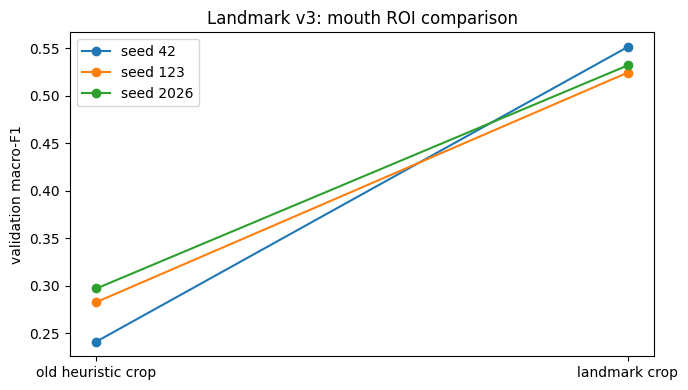

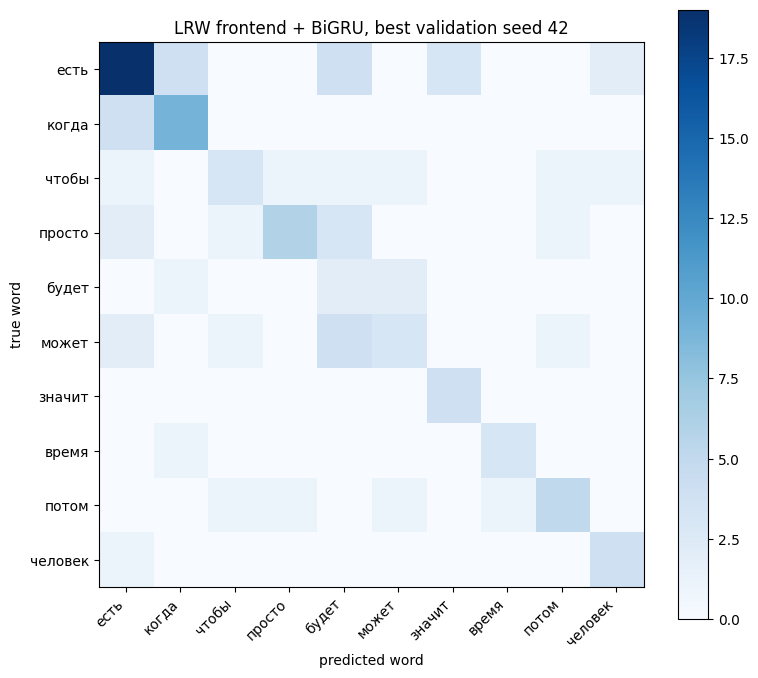

In [11]:
metric_columns = [
    'validation_accuracy',
    'validation_macro_f1',
    'validation_balanced_accuracy',
    'predicted_classes',
]
lrw_summary = lrw_runs[metric_columns].agg(['mean', 'std']).T
lrw_summary.columns = ['lrw_mean', 'lrw_std']

if not old_crop_runs_path.exists():
    raise FileNotFoundError(
        'Previous old-crop LRW multiseed CSV was not found: '
        + str(old_crop_runs_path)
    )

all_old_crop_runs = pd.read_csv(old_crop_runs_path)
old_crop_runs = all_old_crop_runs[
    all_old_crop_runs['dataset_version'] == 'v2'
].copy()
old_crop_summary = old_crop_runs[metric_columns].agg(['mean', 'std']).T
old_crop_summary.columns = ['old_crop_mean', 'old_crop_std']
comparison = old_crop_summary.join(lrw_summary).reset_index(names='metric')
comparison['lrw_minus_old_crop_mean'] = (
    comparison['lrw_mean'] - comparison['old_crop_mean']
)
display(comparison)

paired = old_crop_runs.set_index('seed')[['validation_macro_f1']].rename(
    columns={'validation_macro_f1': 'old_crop_macro_f1'}
).join(
    lrw_runs.set_index('seed')[['validation_macro_f1']].rename(
        columns={'validation_macro_f1': 'lrw_macro_f1'}
    )
)
paired['lrw_minus_old_crop_macro_f1'] = (
    paired['lrw_macro_f1'] - paired['old_crop_macro_f1']
)
display(paired)

comparison.to_csv(output_dir / 'lrw_vs_old_crop_summary.csv', index=False)
paired.to_csv(output_dir / 'lrw_vs_old_crop_paired_macro_f1.csv')
lrw_summary.reset_index(names='metric').to_csv(
    output_dir / 'lrw_frontend_bigru_landmark_v3_multiseed_summary.csv', index=False
)

fig, ax = plt.subplots(figsize=(7, 4))
for seed, row in paired.iterrows():
    ax.plot(
        ['old heuristic crop', 'landmark crop'],
        [row['old_crop_macro_f1'], row['lrw_macro_f1']],
        marker='o',
        label=f'seed {seed}',
    )
ax.set_ylabel('validation macro-F1')
ax.set_title('Landmark v3: mouth ROI comparison')
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / 'lrw_vs_old_crop_macro_f1.png', dpi=150)
plt.show()

best_seed = int(lrw_runs.sort_values('validation_macro_f1').iloc[-1]['seed'])
matrix = metrics_by_seed[best_seed]['confusion_matrix']
fig, ax = plt.subplots(figsize=(8, 7))
image = ax.imshow(matrix, cmap='Blues')
ax.set_title(f'LRW frontend + BiGRU, best validation seed {best_seed}')
ax.set_xlabel('predicted word')
ax.set_ylabel('true word')
ax.set_xticks(range(len(vocab)), vocab, rotation=45, ha='right')
ax.set_yticks(range(len(vocab)), vocab)
fig.colorbar(image, ax=ax)
fig.tight_layout()
fig.savefig(output_dir / 'lrw_frontend_best_confusion_matrix.png', dpi=150)
plt.show()

## 12. Decision gate

In [12]:
lrw_mean = lrw_runs['validation_macro_f1'].mean()
old_crop_mean = old_crop_runs['validation_macro_f1'].mean()
delta = lrw_mean - old_crop_mean
wins = int((paired['lrw_minus_old_crop_macro_f1'] > 0).sum())

print('Landmark crop mean macro-F1:', round(lrw_mean, 4))
print('Old crop mean macro-F1:', round(old_crop_mean, 4))
print('mean landmark - old crop:', round(delta, 4))
print('Landmark crop wins by seed:', f'{wins}/{len(SEEDS)}')

if delta > 0 and wins >= 2:
    print('DECISION: landmark alignment helps.')
    print('Use this preprocessing for evaluation on a new untouched test set.')
else:
    print('DECISION: landmark crop does not improve reliably.')
    print('Do not open test. Inspect domain/preprocessing mismatch before fine-tuning.')

print('TEST SPLIT WAS NOT USED.')

Landmark crop mean macro-F1: 0.5359
Old crop mean macro-F1: 0.2736
mean landmark - old crop: 0.2622
Landmark crop wins by seed: 3/3
DECISION: landmark alignment helps.
Use this preprocessing for evaluation on a new untouched test set.
TEST SPLIT WAS NOT USED.
